In [1]:
import numpy as np
import polars as pl
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from working_data import clean_cols, clean_non_minute_rows, alt_label_df as label_df, normalize_by_window, split_df, chunky_split_df
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from model_builder_trans import combined_loss
from scipy.signal import savgol_filter



2025-04-09 16:48:07.408066: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-09 16:48:07.516690: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-09 16:48:08.717966: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-04-09 16:48:10.584306: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-09 16:48:10.776715: 

In [2]:
NORMALIZING_WINDOW_SIZE = 6*24
LABELING_WINDOW_SIZE = 12
POSITIVE_SLOPE = 0.3
LABEL_CUR_CANDLE_MULTIPLIER = 0
LABEL_MEAN_MULTIPLIER = 6
BATCH_SIZE = 512
NUM_TOKENS = 64
LOOKBACK_WINDOW = NUM_TOKENS + 1
D_MODEL = 384
FF_DIM = D_MODEL*2
NUM_HEADS = D_MODEL//24

In [3]:
source_csv = "olderdata/GBPUSD/five_minutes.csv"
working_path = "working"

In [4]:
df = pd.read_csv(source_csv)
# df = clean_non_minute_rows(df)
df = clean_cols(df)
df = normalize_by_window(
    df, 
    window_size=NORMALIZING_WINDOW_SIZE, 
    normalizing_cols=[
        'open',
        'high',
        'low',
        'close',
    ])
print("labeling")
df = label_df(df, window_size=LABELING_WINDOW_SIZE, mean_multiplier=LABEL_MEAN_MULTIPLIER, cur_candle_multiplier=LABEL_CUR_CANDLE_MULTIPLIER)
print(df['target'].value_counts())
split_df(
    df=df, 
    dump_path=working_path,
    lookback=LOOKBACK_WINDOW,
    cols=[
        'open',
        'high',
        'low',
        'close',
        'open_normalized',
        'high_normalized',
        'low_normalized',
        'close_normalized',
        'target'
    ])

In [5]:
def prepare_data(file_path, num_tokens, window_size=1440, batch_size=32, smote=False, shuffle=False, cols=['open', 'high', 'low', 'close']):
    emd_range = window_size
    # Load CSV lazily with Polars
    collect_cols = cols + ['target']
    df_lazy = pl.scan_csv(file_path).select(collect_cols)
    
    # Collect the dataframe and determine total number of rows
    df_collected = df_lazy.collect()
    total_rows = df_collected.shape[0]
    if smote:
        df_collected = df_collected.with_columns(pl.arange(0, total_rows).alias("index"))
        indices_target_1 = df_collected.filter(
            (pl.col("target") == 1) & (pl.col("index") >= emd_range)
        ).select("index").to_series().to_list()

        # Get indices where target is 0 and >= num_tokens
        indices_target_0 = df_collected.filter(
            (pl.col("target") == 0) & (pl.col("index") >= emd_range)
        ).select("index").to_series().to_list()

        df_collected = df_collected.drop('index')
    
    while True:  # Loop to reshuffle and restart at each epoch
        # Create an array of indices to use for shuffling
        indices = list(range(emd_range, total_rows))
        if smote:
            indices_target_1_complete = []
            while len(indices_target_1_complete) < len(indices_target_0):
                indices_target_1_complete += indices_target_1

            indices_target_1_complete = indices_target_1_complete[:len(indices_target_0)]

            indices = indices_target_0 + indices_target_1_complete

        # Shuffle indices if required
        if shuffle:
            np.random.shuffle(indices)

        input_list = []
        target_list = []

        for idx in indices:
            #create imfs
            signal = np.array(df_collected[cols][idx - emd_range + 1:idx + 1])
            
            # signal = scaler.fit_transform(signal)

            # Fetch the previous `num_prev + 1` rows for the input based on the current index
            input_rows = signal[-num_tokens:]
            target_value = df_collected[idx, -1]  # Get 'target' for the target

            # Append the input rows to the input list
            input_list.append(input_rows)
            target_list.append(target_value)

            # Yield once we have enough for a batch
            if len(input_list) == batch_size:
                # Convert lists to NumPy arrays
                input_array = np.array(input_list)
                target_array = np.array(target_list)

                # Convert NumPy arrays to TensorFlow tensors
                input_tensor = tf.convert_to_tensor(input_array, dtype=tf.float32)
                target_tensor = tf.convert_to_tensor(target_array, dtype=tf.int32)

                yield input_tensor, target_tensor

                # Reset lists for the next batch

                input_list.clear()
                target_list.clear()

        break

In [6]:
def create_dataset_generator(file_path, batch_size, num_tokens, window_size=LOOKBACK_WINDOW, shuffle=False, repeat=False, smote=False, cols=['open', 'high', 'low', 'close']):
    dataset = tf.data.Dataset.from_generator(
        lambda: prepare_data(file_path, window_size=window_size, batch_size=batch_size, num_tokens=num_tokens, shuffle=shuffle, smote=smote, cols=cols),
        output_signature=(
            tf.TensorSpec(shape=(None, num_tokens, len(cols)), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.int32)
        )
    )
    if repeat:
        dataset = dataset.repeat()
    return dataset 

In [7]:
def get_total_rows(file_path, num_tokens, smote=False):
    # Count the total number of rows in the CSV file
    df_lazy = pl.scan_csv(file_path)
    df_collected = df_lazy.collect()
    total_rows = df_collected.shape[0]
    if not smote:
        return total_rows
    df_collected = df_collected.with_columns(pl.arange(0, total_rows).alias("index"))
    indices_target_0 = df_collected.filter(
            (pl.col("target") == 0) & (pl.col("index") >= num_tokens)
    )
    return len(indices_target_0) * 2

In [8]:
train_path = 'working/train.csv'
val_path = 'working/val.csv'
test_path = 'working/test.csv'

cols = [
    'open_normalized',
    'high_normalized',
    'low_normalized',
    'close_normalized'
]

train_dataset = create_dataset_generator(train_path, batch_size=BATCH_SIZE, num_tokens=NUM_TOKENS, repeat=True, shuffle=True, smote=True, cols=cols)
val_dataset = create_dataset_generator(val_path, batch_size=BATCH_SIZE, num_tokens=NUM_TOKENS, repeat=True, cols=cols)
test_dataset = create_dataset_generator(test_path, batch_size=BATCH_SIZE, num_tokens=NUM_TOKENS, cols=cols)

train_steps = get_total_rows(train_path, num_tokens=LOOKBACK_WINDOW, smote=True)//BATCH_SIZE
val_steps = get_total_rows(val_path, num_tokens=LOOKBACK_WINDOW)//BATCH_SIZE
test_steps = get_total_rows(test_path, num_tokens=LOOKBACK_WINDOW)//BATCH_SIZE

In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, GlobalMaxPooling1D, GlobalAveragePooling1D, Flatten, Dense, concatenate, LayerNormalization, Dropout, Lambda, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.layers import MultiHeadAttention, Add, Embedding

input_length = NUM_TOKENS 

class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, maxlen, d_model):
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self.positional_encoding(maxlen, d_model)

    def positional_encoding(self, maxlen, d_model):
        positions = np.arange(maxlen)[:, np.newaxis]
        angles = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (angles // 2)) / np.float32(d_model))
        angle_rads = positions * angle_rates

        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]
    
class LearnablePositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, maxlen, d_model):
        super(LearnablePositionalEncoding, self).__init__()
        self.pos_emb = tf.keras.layers.Embedding(input_dim=maxlen, output_dim=d_model)
        
    def call(self, inputs):
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        positions = self.pos_emb(positions)
        # Add the position embeddings to the input embeddings
        # Remove the erroneous newaxis dimension
        return inputs + positions[tf.newaxis, :, :]


class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu"), Dense(embed_dim)]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)
    
class GatedTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(GatedTransformerBlock, self).__init__()
        # self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, 
            key_dim=embed_dim // num_heads 
        )
        
        # Gating mechanism for attention
        self.gate_att = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Feed forward network with gating
        self.ff1 = tf.keras.layers.Dense(ff_dim, activation="relu")
        self.ff2 = tf.keras.layers.Dense(embed_dim)
        self.gate_ffn = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Normalization and dropout layers
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=True):
        # Self-attention with gating
        attn_output = self.att(inputs, inputs)
        gate_val = self.gate_att(inputs)
        attn_output = gate_val * attn_output
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        
        # Feed-forward network with gating
        ffn_output = self.ff1(out1)
        ffn_output = self.ff2(ffn_output)
        gate_val = self.gate_ffn(out1)
        ffn_output = gate_val * ffn_output
        ffn_output = self.dropout2(ffn_output, training=training)
        
        return self.layernorm2(out1 + ffn_output)


class MemoryEfficientGatedTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(MemoryEfficientGatedTransformerBlock, self).__init__()
        self.embed_dim = embed_dim
        
        # Custom attention components
        self.query_dense = Dense(embed_dim)
        self.key_dense = Dense(embed_dim)
        self.value_dense = Dense(embed_dim)
        self.attention = tf.keras.layers.Attention(use_scale=True)
        
        # Gating mechanism for attention
        self.gate_att = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Feed forward network with gating
        self.ff1 = tf.keras.layers.Dense(ff_dim, activation="relu")
        self.ff2 = tf.keras.layers.Dense(embed_dim)
        self.gate_ffn = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Normalization and dropout layers
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=True):
        # Generate Q, K, V
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        
        # Apply attention
        attn_output = self.attention([query, key, value])
        
        # Apply gating to attention output
        gate_val = self.gate_att(inputs)
        attn_output = gate_val * attn_output
        
        # Apply dropout and add residual connection
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        
        # Feed-forward network with gating
        ffn_output = self.ff1(out1)
        ffn_output = self.ff2(ffn_output)
        gate_val = self.gate_ffn(out1)
        ffn_output = gate_val * ffn_output
        ffn_output = self.dropout2(ffn_output, training=training)
        
        return self.layernorm2(out1 + ffn_output)
    
class StochasticGatedTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, 
                 attention_dropout=0.1, stochastic_depth_rate=0.1):
        super(StochasticGatedTransformerBlock, self).__init__()
        
        # Standard multi-head attention from original implementation
        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, 
            key_dim=embed_dim//num_heads,  # key_dim is per head
            dropout=attention_dropout
        )
        # self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=attention_dropout)
        
        self.stochastic_depth_rate = stochastic_depth_rate
        
        # Gating mechanism for attention with stochastic noise
        self.gate_att = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Feed forward network with gating
        self.ff1 = tf.keras.layers.Dense(ff_dim, activation="relu")
        self.ff2 = tf.keras.layers.Dense(embed_dim)
        self.gate_ffn = tf.keras.layers.Dense(embed_dim, activation='sigmoid')
        
        # Normalization and dropout layers
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def stochastic_depth(self, x, training):
        """Applies stochastic depth to the input tensor."""
        if not isinstance(training, bool):
            training = tf.cast(training, tf.bool)
            
        # Create binary tensor with probability of keeping activations
        keep_prob = 1.0 - self.stochastic_depth_rate
        
        def drop_path():
            batch_size = tf.shape(x)[0]
            random_tensor = keep_prob
            random_tensor += tf.random.uniform([batch_size, 1, 1], dtype=x.dtype)
            binary_tensor = tf.floor(random_tensor)
            # Scale the activations
            return x * binary_tensor / keep_prob
            
        output = tf.cond(
            tf.logical_and(training, tf.constant(self.stochastic_depth_rate > 0)),
            lambda: drop_path(),
            lambda: x
        )
        
        return output

    def call(self, inputs, training=True):
        # Convert string 'True' to boolean True if needed
        if isinstance(training, str):
            training = training == 'True'
            
        # Handle stochastic depth with tf.cond
        def skip_block():
            return inputs
            
        def process_block():
            # Apply noise during training
            def apply_training_noise():
                noise_scale = 0.01
                input_noise = tf.random.normal(tf.shape(inputs), stddev=noise_scale)
                return inputs + input_noise
                
            inputs_with_noise = tf.cond(
                tf.cast(training, tf.bool),
                lambda: apply_training_noise(),
                lambda: inputs
            )
                
            # Apply multi-head attention
            attn_output = self.att(inputs_with_noise, inputs_with_noise)
            
            # Apply gating to attention output
            gate_val = self.gate_att(inputs)
            
            # Add multiplicative noise to gates during training
            def add_gate_noise():
                gate_noise = tf.random.normal(tf.shape(gate_val), mean=1.0, stddev=0.1)
                return gate_val * gate_noise
                
            gate_val = tf.cond(
                tf.cast(training, tf.bool),
                lambda: add_gate_noise(),
                lambda: gate_val
            )
                
            attn_output = gate_val * attn_output
            
            # Apply dropout and add residual connection
            attn_output = self.dropout1(attn_output, training=training)
            out1 = self.layernorm1(inputs + attn_output)
            
            # Feed-forward network with gating
            ffn_output = self.ff1(out1)
            
            # Apply stochastic feature dropout during training
            def apply_feature_dropout():
                # Randomly zero out some features
                feature_mask = tf.cast(
                    tf.random.uniform(tf.shape(ffn_output)) > 0.1, 
                    dtype=ffn_output.dtype
                )
                return ffn_output * feature_mask * 1.1  # Scale to maintain expected value
                
            ffn_output = tf.cond(
                tf.cast(training, tf.bool),
                lambda: apply_feature_dropout(),
                lambda: ffn_output
            )
                
            ffn_output = self.ff2(ffn_output)
            gate_val = self.gate_ffn(out1)
            
            # Add noise to FFN gates during training
            def add_ffn_gate_noise():
                gate_noise = tf.random.normal(tf.shape(gate_val), mean=1.0, stddev=0.1)
                return gate_val * gate_noise
                
            gate_val = tf.cond(
                tf.cast(training, tf.bool),
                lambda: add_ffn_gate_noise(),
                lambda: gate_val
            )
                
            ffn_output = gate_val * ffn_output
            ffn_output = self.dropout2(ffn_output, training=training)
            
            # Apply stochastic depth to the residual connection
            ffn_output = self.stochastic_depth(ffn_output, training)
            
            return self.layernorm2(out1 + ffn_output)
        
        # Use tf.cond for the main block execution decision
        random_value = tf.random.uniform([])
        skip_condition = tf.logical_and(
            tf.cast(training, tf.bool),
            tf.less(random_value, tf.constant(self.stochastic_depth_rate))
        )
        
        return tf.cond(skip_condition, skip_block, process_block)
        
    def compute_output_shape(self, input_shape):
        return input_shape

In [10]:
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr=1e-3, warmup_steps=1000, decay_steps=10000):
        super(WarmupCosineDecay, self).__init__()
        self.initial_lr = initial_lr
        self.warmup_steps = warmup_steps
        self.decay_steps = decay_steps
        
    def __call__(self, step):
        # Linear warmup
        warmup_lr = self.initial_lr * (tf.cast(step, tf.float32) / 
                                      tf.cast(self.warmup_steps, tf.float32))
        
        # Cosine decay
        cosine_decay = 0.5 * (1 + tf.cos(
            3.14159 * (tf.cast(step, tf.float32) - self.warmup_steps) / 
            tf.cast(self.decay_steps - self.warmup_steps, tf.float32)))
        decay_lr = self.initial_lr * cosine_decay
        
        # Use warmup_lr for the first warmup_steps, then decay_lr
        lr = tf.where(step < self.warmup_steps, warmup_lr, decay_lr)
        return lr
    
    def get_config(self):
        """Required for serialization when saving the model."""
        return {
            "initial_lr": self.initial_lr,
            "warmup_steps": self.warmup_steps,
            "decay_steps": self.decay_steps
        }

In [11]:
auc =  tf.keras.metrics.AUC()
auc.reset_state()
prec = tf.keras.metrics.Precision()
prec.reset_state()

In [12]:
def create_model(training=True):
    input_shape = (NUM_TOKENS, 4)
    input_layer = Input(shape=input_shape)
    
    # Initial convolution layers
    x = Conv1D(filters=D_MODEL//2, kernel_size=3, activation='relu', padding="same")(input_layer)
    x = Conv1D(filters=D_MODEL//2, kernel_size=3, activation='relu', padding="same")(x)
    
    # Pooling layers
    max_pool = MaxPooling1D(pool_size=2, padding="same")(x)
    average_pool = AveragePooling1D(pool_size=2, padding="same")(x)
    x = concatenate([max_pool, average_pool], axis=-1)
    x = Dropout(0.1)(x)
    
    # Position encoding
    max_seq_len_after_pooling = NUM_TOKENS // 2
    x = LearnablePositionalEncoding(maxlen=max_seq_len_after_pooling, d_model=D_MODEL)(x)
    
    # Transformer blocks
    x = StochasticGatedTransformerBlock(
        D_MODEL, NUM_HEADS, FF_DIM, 
        rate=0.1, attention_dropout=0.1, stochastic_depth_rate=0.1
    )(x, training=training)
    x = StochasticGatedTransformerBlock(
        D_MODEL, NUM_HEADS, FF_DIM, 
        rate=0.1, attention_dropout=0.1, stochastic_depth_rate=0.2
    )(x, training=training)
    
    # Global pooling features
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    
    # # Combine features from attention pooling and global pooling
    x = concatenate([avg_pool, max_pool])
    
    # Final classifier
    outputs = Dense(1, activation='sigmoid')(x)
    
    # Create model
    model = Model(inputs=input_layer, outputs=outputs)
    
    return model

model = create_model(training=True)

lr_schedule = WarmupCosineDecay(initial_lr=1e-3, warmup_steps=1000, decay_steps=10000)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
# model.load_weights("best_cnn_trans_model.keras", skip_mismatch=True)




# Compile the model
model.compile(
    optimizer=optimizer, 
    loss=combined_loss, 
    metrics=['accuracy',auc, prec])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 64, 192)   │      2,496 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 64, 192)   │    110,784 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 32, 192)   │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d   │ (None, 32, 192)   │          0 │ conv1d_1[0][0]    │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 384)   │          0 │ max_pooling1d[0]… │
│ (Concatenate)       │                   │            │ average_pooling1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 384)   │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learnable_position… │ (None, 32, 384)   │     12,288 │ dropout[0][0]     │
│ (LearnablePosition… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stochastic_gated_t… │ (None, 32, 384)   │  1,479,552 │ learnable_positi… │
│ (StochasticGatedTr… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stochastic_gated_t… │ (None, 32, 384)   │  1,479,552 │ stochastic_gated… │
│ (StochasticGatedTr… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 384)       │          0 │ stochastic_gated… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 384)       │          0 │ stochastic_gated… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 768)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │        769 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,085,441 (11.77 MB)

 Trainable params: 3,085,441 (11.77 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=3, # Stops if there's no improvement in precision for 5 epochs
                               mode='min', 
                               verbose=1)

model_checkpoint = ModelCheckpoint('best_cnn_trans_model.keras', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   mode='min', 
                                   verbose=1)

# model.load_weights('best_cnn_trans_model.keras', skip_mismatch=True)

# Train the model using the train and validation datasets
history = model.fit(
    train_dataset,
    epochs=50,
    steps_per_epoch = train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    callbacks=[early_stopping, model_checkpoint]
)


model = create_model(training=False)


# Load the best model after training
model.load_weights('best_cnn_trans_model.keras')


Epoch 1/50


I0000 00:00:1744210097.776756   99605 service.cc:145] XLA service 0x7fe79400a2a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744210097.776881   99605 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2025-04-09 16:48:18.157760: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1744210098.354571   99605 random_ops.cc:59] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. functional_1/stochastic_gated_transformer_block_1/random_uniform/RandomUniform
2025-04-09 16:48:19.063996: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1744210104.265701   99727 asm_compiler.cc:369] ptxas warning : Registers are

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.6345 - auc: 0.6827 - loss: 1.0143 - precision_1: 0.6330
Epoch 1: val_loss improved from inf to 0.89792, saving model to best_cnn_trans_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 313s 375ms/step - accuracy: 0.6346 - auc: 0.6828 - loss: 1.0141 - precision_1: 0.6331 - val_accuracy: 0.7527 - val_auc: 0.8803 - val_loss: 0.8979 - val_precision_1: 0.1598
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.7932 - auc: 0.8599 - loss: 0.7131 - precision_1: 0.7606
Epoch 2: val_loss did not improve from 0.89792
782/782 ━━━━━━━━━━━━━━━━━━━━ 293s 375ms/step - accuracy: 0.7932 - auc: 0.8599 - loss: 0.7131 - precision_1: 0.7606 - val_accuracy: 0.7002 - val_auc: 0.8746 - val_loss: 1.0249 - val_precision_1: 0.1378
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.8041 - auc: 0.8690 - loss: 0.6910 - precision_1: 0.7664
Epoch 3: val_loss improved from 0.89792 to 0.88678, saving model to best_cnn_trans_model.keras
782/

In [14]:
predictions = model.predict(test_dataset)

# Convert probabilities to binary class (0 or 1) using a threshold of 0.5
predicted_class = (predictions > 0.5).astype(int)

87/87 ━━━━━━━━━━━━━━━━━━━━ 30s 309ms/step


2025-04-09 17:30:08.389483: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
y_true = []

for input_tensor, target_tensor in test_dataset:
    y_true.extend(target_tensor.numpy()) 

2025-04-09 17:30:35.222009: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Confusion Matrix:
 [[33395  8962]
 [  465  1722]]


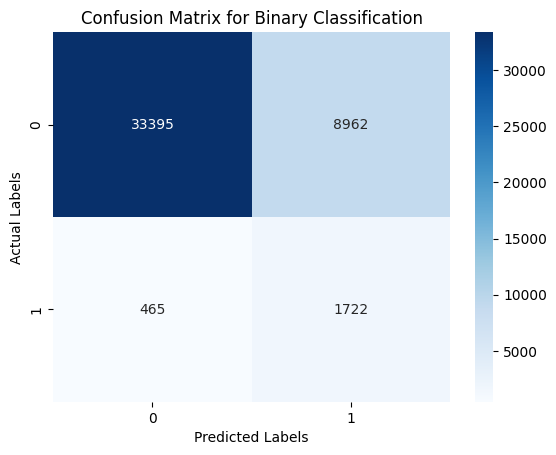

In [17]:
conf_matrix = confusion_matrix(y_true, predicted_class)

print("Confusion Matrix:\n", conf_matrix)

# Optionally: Visualize the confusion matrix using a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for Binary Classification')
plt.show()

In [18]:
model.evaluate(test_dataset)

ValueError: You must call `compile()` before using the model.

In [ ]:
model.save_weights('cnn_trans_layer_4.weights.h5')